In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Load dữ liệu
data_path = Path('../data/student_health_dataset_50k.csv')
df = pd.read_csv(data_path)

print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"Target column (health_condition): {df['health_condition'].unique()}")
print(f"\nDữ liệu đã load thành công!")


Dataset shape: (50000, 16)
Columns: ['student_id', 'timestamp', 'sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure', 'step_count', 'exercise_duration', 'water_intake', 'diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol', 'gender', 'health_condition']
Target column (health_condition): <StringArray>
['at-risk', 'unhealthy', 'fit']
Length: 3, dtype: str

Dữ liệu đã load thành công!


In [15]:
# Cell 1: Tính độ tương quan giữa các thuộc tính
import numpy as np
import pandas as pd
import math
from sklearn.preprocessing import LabelEncoder

# Bước 1: Chỉ lấy dữ liệu từ 2 cột, 1 cột health_condition là target label, 1 cột khác (ví dụ: sleep_duration)
col_chosen = 'sleep_duration'

df_subset = df[['health_condition', col_chosen]].copy()

# Encode health_condition sang numeric
le = LabelEncoder()
df_subset['health_condition'] = le.fit_transform(df_subset['health_condition'])
df_subset[col_chosen] = pd.to_numeric(df_subset[col_chosen], errors='coerce')

# Bỏ qua các giá trị NaN nếu có
df_subset = df_subset.dropna()

x = df_subset[col_chosen].values
y = df_subset['health_condition'].values

# Bước 2: Công thức tính độ tương quan Pearson
def pearson_correlation(x, y):
    if len(x) != len(y):
        raise ValueError("Độ dài của x và y không bằng nhau!")
        
    n = len(x)
    if n == 0:
        return 0
        
    mean_x = sum(x) / n
    mean_y = sum(y) / n
    
    # Tử số: Tổng tích của các sai lệch
    tu_so = sum((x_i - mean_x) * (y_i - mean_y) for x_i, y_i in zip(x, y))
    
    # Mẫu số: Căn bậc 2 của tích các tổng bình phương sai lệch
    sum_sq_x = sum((x_i - mean_x)**2 for x_i in x)
    sum_sq_y = sum((y_i - mean_y)**2 for y_i in y)
    mau_so = math.sqrt(sum_sq_x * sum_sq_y)
    
    if mau_so == 0:
        return 0
        
    return tu_so / mau_so

r = pearson_correlation(x, y)

print(f"Hệ số tương quan Pearson giữa '{col_chosen}' và 'health_condition': {r:.4f}")

# Bước 3: Đưa ra kết luận dựa trên hệ số r
print("Kết luận:")
abs_r = abs(r)

if abs_r == 1.0:
    print("-> Quan hệ tuyến tính hoàn hảo.")
elif 0.7 <= abs_r < 1.0:
    print("-> Quan hệ tuyến tính chặt chẽ.")
elif 0.3 <= abs_r < 0.7:
    print("-> Quan hệ tuyến tính trung bình.")
else:
    print("-> Rất ít hoặc không có quan hệ tuyến tính.")

print("\n✓ Cell 1: Tính độ tương quan hoàn tất!")

Hệ số tương quan Pearson giữa 'sleep_duration' và 'health_condition': 0.0671
Kết luận:
-> Rất ít hoặc không có quan hệ tuyến tính.

✓ Cell 1: Tính độ tương quan hoàn tất!


In [6]:
# Cell 2: Tìm tập phổ biến và luật kết hợp
import pandas as pd
import numpy as np
from itertools import combinations

print("="*80)
print("BÀI TOÁN TÌM TẬP PHỔ BIẾN VÀ LUẬT KẾT HỢP")
print("="*80)

# ========== BƯỚC 1: CẢI THIỆN DỮ LIỆU ==========
print("\n[BƯỚC 1] CẢI THIỆN DỮ LIỆU")

# Bỏ các cột không cần thiết
df_clean = df.drop(columns=['student_id', 'timestamp'])
print(f"✓ Bỏ timestamp, student_id → Còn {len(df_clean.columns)} cột")

# Chuyển cột số thành low/mid/high
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
df_cat = df_clean.copy()

for col in numeric_cols:
    q1, q2 = df_cat[col].quantile([0.33, 0.67])
    df_cat[col] = pd.cut(df_cat[col], bins=[-np.inf, q1, q2, np.inf], labels=['low', 'mid', 'high'], include_lowest=True)

df_cat = df_cat.dropna().sample(n=300, random_state=42)
print(f"✓ Chuyển 7 cột số thành low/mid/high, lấy mẫu {len(df_cat)} giao tác")

# Tạo giao tác
trans = [set(f"{c}_{v}" for c, v in row.items()) for _, row in df_cat.iterrows()]
print(f"✓ Tạo {len(trans)} giao tác\n")

# ========== BƯỚC 2: TÌM TẬP PHỔ BIẾN ==========
print("[BƯỚC 2] TÌM TẬP PHỔ BIẾN")

min_sup = 0.05
min_sup_count = max(1, int(np.ceil(min_sup * len(trans))))
print(f"✓ min_sup = {min_sup} → min_sup_count = {min_sup_count}\n")

# Hàm hỗ trợ: sinh candidate set từ frequent itemset
def generate_candidates(frequent_set, k):
    candidates = set()
    items = list(frequent_set)
    for i in range(len(items)):
        for j in range(i + 1, len(items)):
            candidate = items[i] | items[j]
            if len(candidate) == k:
                candidates.add(candidate)
    return candidates

# Apriori Algorithm - Mở rộng
all_frequent_itemsets = {}
all_candidates = {}

# === F1 ===
print("F1 (Itemsets có 1 phần tử):")
print("-" * 80)
C1 = {}
for t in trans:
    for item in t:
        item_set = frozenset([item])
        C1[item_set] = C1.get(item_set, 0) + 1

print(f"Số lượng candidates (C1): {len(C1)}")
all_candidates[1] = len(C1)

F1 = {k: v for k, v in C1.items() if v >= min_sup_count}
print(f"Số lượng frequent itemsets (F1): {len(F1)}")
all_frequent_itemsets[1] = F1
print(f"✓ Tìm được: {len(F1)}/{len(C1)} itemsets\n")

# === F2, F3, ... ===
k = 2
previous_frequent = list(F1.keys())

while len(previous_frequent) >= k - 1:
    # Sinh candidates Ck
    Ck = set()
    for i in range(len(previous_frequent)):
        for j in range(i + 1, len(previous_frequent)):
            candidate = previous_frequent[i] | previous_frequent[j]
            if len(candidate) == k:
                Ck.add(candidate)

    if not Ck:
        break

    # Đếm support cho từng candidate
    Fk = {}
    for c in Ck:
        cnt = sum(1 for t in trans if c <= t)
        if cnt >= min_sup_count:
            Fk[c] = cnt

    print(f"F{k} (Itemsets có {k} phần tử):")
    print("-" * 80)
    print(f"Số lượng candidates (C{k}): {len(Ck)}")
    all_candidates[k] = len(Ck)
    print(f"Số lượng frequent itemsets (F{k}): {len(Fk)}")
    all_frequent_itemsets[k] = Fk
    print(f"✓ Tìm được: {len(Fk)}/{len(Ck)} itemsets\n")

    if not Fk:
        break

    previous_frequent = list(Fk.keys())
    k += 1

# Tổng hợp tất cả frequent itemsets
all_itemsets = []
for k_level, itemsets_dict in sorted(all_frequent_itemsets.items()):
    for itemset, sup in itemsets_dict.items():
        all_itemsets.append((itemset, sup, sup / len(trans)))

# Sắp xếp theo số lượng phần tử giảm dần, rồi support giảm dần
all_itemsets.sort(key=lambda x: (len(x[0]), x[1], x[2]), reverse=True)

# ========== HIỂN THỊ 10 TẬP PHỔ BIẾN ==========
print("="*80)
print("TOP 10 TẬP PHỔ BIẾN TÌM ĐƯỢC:")
print("="*80)
for idx, (itemset, sup, sup_ratio) in enumerate(all_itemsets[:10], 1):
    items_str = ", ".join(sorted(itemset))
    print(f"{idx:2d}. [{len(itemset)} phần tử] {{{items_str}}}")
    print(f"    Support: {sup} ({sup_ratio*100:.2f}%)\n")

# ========== TÌM TẬP PHỔ BIẾN TỐI ĐẠI (MAXIMAL ITEMSETS) ==========
print("\n" + "="*80)
print("TOP 5 TẬP PHỔ BIẾN TỐI ĐẠI (MAXIMAL ITEMSETS) TÌM ĐƯỢC:")
print("="*80)

maximal_itemsets = []
for itemset, sup, sup_ratio in all_itemsets:
    is_maximal = True
    for other_itemset, _, _ in all_itemsets:
        if itemset < other_itemset:
            is_maximal = False
            break
    if is_maximal:
        maximal_itemsets.append((itemset, sup, sup_ratio))

maximal_itemsets.sort(key=lambda x: (len(x[0]), x[1], x[2]), reverse=True)

for idx, (itemset, sup, sup_ratio) in enumerate(maximal_itemsets[:5], 1):
    items_str = ", ".join(sorted(itemset))
    print(f"{idx}. [{len(itemset)} phần tử] {{{items_str}}}")
    print(f"   Support: {sup} ({sup_ratio*100:.2f}%)\n")

# ========== BƯỚC 3: SINH LUẬT KẾT HỢP ==========
print("\n" + "="*80)
print("[BƯỚC 3] SINH LUẬT KẾT HỢP")
print("="*80)

# Sinh luật từ F2 (và F3 nếu có)
F2_and_above = {}
for k_level, itemsets_dict in sorted(all_frequent_itemsets.items()):
    if k_level >= 2:
        for itemset, sup in itemsets_dict.items():
            F2_and_above[itemset] = sup

rules = []
for itemset, sup_xy in F2_and_above.items():
    items_list = list(itemset)
    for i in range(len(items_list)):
        for j in range(len(items_list)):
            if i != j:
                X_item = items_list[i]
                Y_item = items_list[j]

                # Tìm support của X
                sup_x = None
                if frozenset([X_item]) in F1:
                    sup_x = F1[frozenset([X_item])]
                elif frozenset([X_item]) in all_frequent_itemsets.get(1, {}):
                    sup_x = all_frequent_itemsets[1][frozenset([X_item])]

                if sup_x is not None:
                    conf = sup_xy / sup_x
                    support_ratio = sup_xy / len(trans)

                    if conf >= 0.5:
                        rules.append({
                            'X': X_item,
                            'Y': Y_item,
                            'conf': conf,
                            'sup_xy': sup_xy,
                            'sup_x': sup_x,
                            'sup_ratio': support_ratio,
                            'itemset_size': len(itemset)
                        })

rules.sort(key=lambda x: (x['itemset_size'], x['sup_xy'], x['conf']), reverse=True)
print(f"\n✓ Tìm tổng cộng {len(rules)} luật (confidence ≥ 0.5)\n")

# ========== HIỂN THỊ TOP 5 LUẬT VỚI Y LÀ HEALTH_CONDITION ==========
print("="*80)
print("TOP 5 LUẬT KẾT HỢP SAO CHO Y LÀ HEALTH_CONDITION:")
print("="*80)

health_condition_rules = []
for rule in rules:
    Y = rule['Y']
    if Y.startswith('health_condition_'):
        health_condition_rules.append(rule)

health_condition_rules.sort(key=lambda x: (x['itemset_size'], x['sup_xy'], x['conf']), reverse=True)

if health_condition_rules:
    for idx, rule in enumerate(health_condition_rules[:5], 1):
        print(f"R{idx}: [{rule['itemset_size']} phần tử] {rule['X']} → {rule['Y']}")
        print(f"     CF({rule['X']} → {rule['Y']}) = SP({rule['X']} ∪ {rule['Y']}) / SP({rule['X']})")
        print(f"     CF = {rule['sup_xy']}/{rule['sup_x']} = {rule['conf']:.4f}")
        print(f"     Support: {rule['sup_ratio']*100:.2f}%\n")
else:
    print("Không tìm thấy luật với Y là health_condition\n")

print("="*80)
print("✓ Cell 2 hoàn tất!")
print("="*80)


BÀI TOÁN TÌM TẬP PHỔ BIẾN VÀ LUẬT KẾT HỢP

[BƯỚC 1] CẢI THIỆN DỮ LIỆU
✓ Bỏ timestamp, student_id → Còn 14 cột
✓ Chuyển 7 cột số thành low/mid/high, lấy mẫu 300 giao tác
✓ Tạo 300 giao tác

[BƯỚC 2] TÌM TẬP PHỔ BIẾN
✓ min_sup = 0.05 → min_sup_count = 15

F1 (Itemsets có 1 phần tử):
--------------------------------------------------------------------------------
Số lượng candidates (C1): 42
Số lượng frequent itemsets (F1): 41
✓ Tìm được: 41/42 itemsets

F2 (Itemsets có 2 phần tử):
--------------------------------------------------------------------------------
Số lượng candidates (C2): 820
Số lượng frequent itemsets (F2): 743
✓ Tìm được: 743/820 itemsets

F3 (Itemsets có 3 phần tử):
--------------------------------------------------------------------------------
Số lượng candidates (C3): 9940
Số lượng frequent itemsets (F3): 1924
✓ Tìm được: 1924/9940 itemsets

F4 (Itemsets có 4 phần tử):
--------------------------------------------------------------------------------
Số lượng candidates

In [7]:
# Cell 3: Tập thô (Rough Set) - Tìm Reduct trên mẫu và Áp dụng sinh luật trên toàn bộ dữ liệu 50k
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import sympy as sp
from sympy.logic.boolalg import to_dnf
from itertools import combinations
import time

start_time = time.time()

# 1. Chuẩn bị dữ liệu (Toàn bộ 50k dòng)
# Bỏ qua student_id, timestamp
cols_to_drop = ['student_id', 'timestamp']
df_filtered = df.drop(columns=[c for c in cols_to_drop if c in df.columns]).copy()

# Chọn các cột số cần thiết và phân khung
num_cols_to_keep = ['water_intake', 'screen_time', 'sitting_time']
numeric_cols = df_filtered.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if col not in num_cols_to_keep and col in df_filtered.columns:
        df_filtered = df_filtered.drop(columns=[col])
    elif col in num_cols_to_keep:
        df_filtered[col] = pd.cut(df_filtered[col], bins=3, labels=['low', 'mid', 'high'])

# 2. Xây dựng ma trận phân biệt trên một MẪU ĐẠI DIỆN để tìm REDUCT
SAMPLE_SIZE = 100
print(f"Bước 1: Trích xuất {SAMPLE_SIZE} mẫu đại diện để tìm tập thuộc tính tối thiểu (Reducts)...\n")
df_sample = df_filtered.sample(n=SAMPLE_SIZE, random_state=42).reset_index(drop=True)

X_sample = df_sample.drop('health_condition', axis=1)
y_sample = df_sample['health_condition']
attributes = list(X_sample.columns)

# Tạo ký hiệu viết tắt cho thuộc tính
attr_symbols = {attr: f"A{i+1}" for i, attr in enumerate(attributes)}
symbol_to_attr = {v: k for k, v in attr_symbols.items()}

# Trình bày như mẫu
dat_str = ", ".join([f'"{attr}"={sym}' for attr, sym in attr_symbols.items()])
print(f"Dat {dat_str}")
print("- Ta co ma tran phan biet nhu sau:")

n = len(df_sample)
discernibility_matrix = [[set() for _ in range(n)] for _ in range(n)]
conditions = []

# Header ma trận (hiển thị 8 mẫu đầu cho dễ nhìn)
n_display = min(8, n)
header = "    " + "  ".join([f"o{j+1:<8}" for j in range(n_display)])
print(header)

for i in range(n):
    row_str = f"o{i+1:<2}"
    for j in range(n):
        if i < j and y_sample.iloc[i] != y_sample.iloc[j]:
            diff_attrs = {attr_symbols[attr] for attr in attributes if X_sample.iloc[i][attr] != X_sample.iloc[j][attr]}
            discernibility_matrix[i][j] = diff_attrs
            if diff_attrs:
                conditions.append(diff_attrs)
        elif i >= j or y_sample.iloc[i] == y_sample.iloc[j]:
            discernibility_matrix[i][j] = set()
            
        if j < n_display and i < n_display:
            if not discernibility_matrix[i][j]:
                row_str += "  λ       "
            else:
                cell_str = "{" + ", ".join(sorted(discernibility_matrix[i][j])) + "}"
                row_str += f"  {cell_str:<8}"
    if i < n_display:
        print(row_str)

unique_conditions = [list(c) for c in set(tuple(sorted(c)) for c in conditions if c)]

def find_reducts_fast(conditions, attributes_syms):
    valid_reducts = []
    for k in range(1, len(attributes_syms) + 1):
        for subset in combinations(attributes_syms, k):
            subset_set = set(subset)
            is_valid = True
            for cond in conditions:
                if not set(cond).intersection(subset_set):
                    is_valid = False
                    break
            if is_valid:
                valid_reducts.append(list(subset))
        if valid_reducts:
             break
    return valid_reducts

sym_list = list(attr_symbols.values())
reducts = find_reducts_fast(unique_conditions, sym_list)

# Hàm phân biệt
function_str = " ∧ ".join(["(" + " ∨ ".join(c) + ")" for c in unique_conditions[:8]]) # In ra một số điều kiện đại diện
if len(unique_conditions) > 8: function_str += " ∧ ..."
args_str = ",".join(sym_list)
print(f"\nHam phan biet:\nF({args_str}) = {function_str}")

# In Reducts
print("\nCac reduct toi thieu tim duoc:")
if not reducts:
    print("Không tìm thấy reduct phân biệt tuyệt đối nào.")
    chosen_red_attr = attributes # Lùi về: lấy tất cả
    print(f"\nChon reduct de sinh luat: {chosen_red_attr}")
else:
    for i, red in enumerate(reducts):
        red_attrs = [symbol_to_attr[s] for s in red]
        print(f"• Reduct{i+1} = {{{', '.join(red)}}} = {red_attrs}")
    
    chosen_red_sym = reducts[0]
    chosen_red_attr = [symbol_to_attr[s] for s in chosen_red_sym]
    print(f"\nChon reduct de sinh luat: {chosen_red_attr}")

# 3. Áp dụng Reduct đã tìm được lên TOÀN BỘ 50.000 dòng để sinh luật
print(f"\n==================================================")
print(f"Bước 2: Áp dụng reduct {chosen_red_attr} lên TOÀN BỘ ({len(df_filtered)} mẫu) bộ dữ liệu...")

def generate_rules_full_data(df_full, reduct_attrs, target_col):
    grouped = df_full.groupby(reduct_attrs)
    rules = []
    rule_count = 1
    
    for name, group in grouped:
        support = len(group)
        if support < 10:
            continue
            
        majority_decision = group[target_col].mode()[0]
        majority_count = len(group[group[target_col] == majority_decision])
        accuracy = majority_count / support
        
        if accuracy >= 0.90:
            if type(name) not in (list, tuple):
                name = (name,)
            condition = " AND ".join([f"{attr}={val}" for attr, val in zip(reduct_attrs, name)])
            rules.append({
                'id': rule_count,
                'condition': condition,
                'decision': majority_decision,
                'accuracy': accuracy * 100,
                'support': support
            })
            rule_count += 1
            
    return sorted(rules, key=lambda x: (x['accuracy'], x['support']), reverse=True)


rules = generate_rules_full_data(df_filtered, chosen_red_attr, 'health_condition')

print(f"\nSau khi lọc (Support >= 10, Conf >= 90%), đã tinh chắt được {len(rules)} luật phân lớp chất lượng cao.")
print("\n--- TOP 10 LUẬT TỐT NHẤT TỪ TOÀN BỘ DỮ LIỆU ---")
for r in rules[:10]:
    print(f"• Luật {r['id']:<3}: IF {r['condition']} THEN health_condition='{r['decision']}' (Độ chính xác: {r['accuracy']:.1f}%, Áp dụng cho: {r['support']} mẫu)")

end_time = time.time()
print(f"\n✓ Cell 3: Áp dụng phương pháp lấy mẫu Reduct trên 50K dòng hoàn tất trong {end_time - start_time:.2f} giây!")

Bước 1: Trích xuất 100 mẫu đại diện để tìm tập thuộc tính tối thiểu (Reducts)...

Dat "water_intake"=A1, "screen_time"=A2, "sitting_time"=A3, "diet_type"=A4, "stress_level"=A5, "sleep_quality"=A6, "physical_activity_level"=A7, "smoking_status"=A8, "alcohol_intake"=A9, "mental_health_status"=A10, "academic_pressure"=A11, "social_relationships"=A12, "gender"=A13
- Ta co ma tran phan biet nhu sau:
    o1         o2         o3         o4         o5         o6         o7         o8       
o1   λ         {A10, A11, A12, A4, A5, A7, A8, A9}  {A11, A12, A13, A3, A4, A5, A6, A7, A8, A9}  λ         {A1, A12, A3, A4, A5, A7, A9}  {A11, A13, A4, A5, A6, A7, A9}  {A1, A10, A11, A4, A6, A7}  {A1, A10, A11, A12, A13, A2, A4, A7, A8, A9}
o2   λ         λ         λ         {A11, A12, A13, A4, A8, A9}  {A1, A10, A11, A3, A4, A5, A8}  λ         λ         λ       
o3   λ         λ         λ         {A10, A11, A12, A13, A3, A4, A6, A8, A9}  {A1, A11, A13, A5, A6, A8}  λ         λ         λ       
o4   λ   

In [8]:
# Cell 4: Phân lớp Bayes 
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

# Mục đích: Thuật toán Phân lớp Bayes yêu cầu dữ liệu được chuẩn bị kỹ
# lưỡng bao gồm các đặc trưng (features) và nhãn (labels).

# Quy trình xử lý dữ liệu:
# - Bỏ qua các cột không liên quan
cols_to_drop = ['student_id', 'timestamp']
df_filtered = df.drop(columns=[c for c in cols_to_drop if c in df.columns]).copy()

# - Tách dữ liệu thành các đặc trưng X và nhãn y
X_raw = df_filtered.drop('health_condition', axis=1).copy()
y_raw = df_filtered['health_condition'].copy()

# (Bước phụ: Xử lý các cột số: chỉ giữ lại một số cột cần thiết và rời rạc hóa)
num_cols_to_keep = ['water_intake', 'screen_time', 'sitting_time']
numeric_cols = X_raw.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if col not in num_cols_to_keep and col in X_raw.columns:
        X_raw = X_raw.drop(columns=[col])
    elif col in num_cols_to_keep:
        X_raw[col] = pd.cut(X_raw[col], bins=3, labels=['low', 'mid', 'high'])

X_encoded = X_raw.copy()

for col in X_encoded.columns:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))

X_vals = X_encoded.values
y_vals = y_raw.values

# - Chia tập dữ liệu thành hai phần: Tập huấn luyện (70%) và Tập kiểm tra (30%)
np.random.seed(42)
indices = np.random.permutation(len(X_vals))
split_idx = int(len(indices) * 0.7)
train_idx, test_idx = indices[:split_idx], indices[split_idx:]

X_train, X_test = X_vals[train_idx], X_vals[test_idx]
y_train, y_test = y_vals[train_idx], y_vals[test_idx]

print(f"Số lượng mẫu huấn luyện (70%): {len(X_train)}")
print(f"Số lượng mẫu kiểm tra (30%): {len(X_test)}")

# Bước 1: Cài đặt lớp NaiveBayesClassifier
class NaiveBayesClassifier:
    def __init__(self, smoothing=True):
        # Khởi tạo mô hình Naïve Bayes với tùy chọn làm trơn Laplace (smoothing).
        self.smoothing = smoothing
        self.alpha = 1.0 if smoothing else 0.0
        self.classes = []
        self.class_probs = {}
        self.feature_probs = {}

    def fit(self, X, y):
        # Học mô hình trên dữ liệu
        self.classes = np.unique(y)
        n_samples, n_features = X.shape
        
        # Tính xác suất tiên nghiệm (prior probabilities)
        for c in self.classes:
            self.class_probs[c] = np.sum(y == c) / n_samples
            
        # Tính xác suất có điều kiện (conditional probabilities) (nếu dùng làm trơn Laplace)
        self.feature_probs = {c: {i: {} for i in range(n_features)} for c in self.classes}
        
        for i in range(n_features):
            unique_values = np.unique(X[:, i])
            V = len(unique_values)
            
            for c in self.classes:
                X_c = X[y == c]
                n_c = len(X_c)
                
                values, counts = np.unique(X_c[:, i], return_counts=True)
                val_count_dict = dict(zip(values, counts))
                
                for val in unique_values:
                    count_val_c = val_count_dict.get(val, 0)
                    
                    # Tính xác suất (có hoặc không có Laplace theo self.alpha)
                    prob = (count_val_c + self.alpha) / (n_c + self.alpha * V)
                    
                    # Tránh xác suất = 0 nếu không smoothing
                    if prob == 0:
                        prob = 1e-10 
                        
                    self.feature_probs[c][i][val] = prob

        # Trả về chi tiết quá trình học để kiểm tra
        return "Quá trình học hoàn tất: Đã tính xong xác suất tiên nghiệm và có điều kiện."

    def predict(self, X):
        # Dự đoán nhãn cho các mẫu mới
        predictions = []
        for x in X:
            posteriors = {}
            for c in self.classes:
                # Tính toán log để tránh tràn số (avoid underflow)
                # Dùng log(P(c)) + sum(log(P(Xi|c))) thay vì nhân trực tiếp
                prior = np.log(self.class_probs[c])
                conditional = 0
                
                for i, val in enumerate(x):
                    # Nếu giá trị chưa từng xuất hiện, cho 1 xác suất cực nhỏ
                    prob = self.feature_probs[c][i].get(val, 1e-10) 
                    conditional += np.log(prob)
                    
                # Công thức Bayes
                posteriors[c] = prior + conditional
            
            # Chọn nhãn có xác suất hậu nghiệm lớn nhất
            best_class = max(posteriors, key=posteriors.get)
            predictions.append(best_class)
            
        # Trả về nhãn dự đoán và chi tiết quá trình
        return np.array(predictions)


# Bước 2: Cài đặt hàm tính toán và đánh giá
def calculate_confusion_matrix(y_true, y_pred, classes):
    # Tạo ma trận nhầm lẫn để kiểm tra kết quả dự đoán (so sánh thực tế và dự đoán)
    matrix = np.zeros((len(classes), len(classes)), dtype=int)
    class_to_idx = {c: i for i, c in enumerate(classes)}
    for t, p in zip(y_true, y_pred):
        if t in class_to_idx and p in class_to_idx:
            matrix[class_to_idx[t], class_to_idx[p]] += 1
    return matrix

def calculate_precision_recall_f1(confusion_matrix, classes):
    metrics = {}
    total_precision = 0
    total_recall = 0
    total_f1 = 0
    
    for i, c in enumerate(classes):
        tp = confusion_matrix[i, i]
        fp = np.sum(confusion_matrix[:, i]) - tp
        fn = np.sum(confusion_matrix[i, :]) - tp
        
        # Precision, Recall, F1-score
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        
        metrics[c] = {'precision': precision, 'recall': recall, 'f1': f1}
        total_precision += precision
        total_recall += recall
        total_f1 += f1
        
    # Trung bình Macro
    n = len(classes)
    metrics['macro_avg'] = {
        'precision': total_precision / n,
        'recall': total_recall / n,
        'f1': total_f1 / n
    }
    return metrics

classes = np.unique(y_raw)


# Bước 3: Cài đặt sử dụng Naive Bayes

# 3.1. triển khai naive_bayes_no_smoothing
print("\n--- 1. Naive Bayes KHÔNG xử lý làm trơn Laplace ---")
naive_bayes_no_smoothing = NaiveBayesClassifier(smoothing=False)
status_no_smooth = naive_bayes_no_smoothing.fit(X_train, y_train)
print(status_no_smooth)

y_pred_no_smooth = naive_bayes_no_smoothing.predict(X_test)
cm_no_smooth = calculate_confusion_matrix(y_test, y_pred_no_smooth, classes)
metrics_no_smooth = calculate_precision_recall_f1(cm_no_smooth, classes)

print("Ma trận nhầm lẫn (Confusion Matrix):")
print(pd.DataFrame(cm_no_smooth, index=classes, columns=classes))
print(f"Đánh giá tổng quát - Precision: {metrics_no_smooth['macro_avg']['precision']:.4f}, Recall: {metrics_no_smooth['macro_avg']['recall']:.4f}, F1-score: {metrics_no_smooth['macro_avg']['f1']:.4f}")


# 3.2. triển khai naive_bayes_with_smoothing
print("\n--- 2. Naive Bayes CÓ áp dụng làm trơn Laplace ---")
naive_bayes_with_smoothing = NaiveBayesClassifier(smoothing=True)
status_smooth = naive_bayes_with_smoothing.fit(X_train, y_train)
print(status_smooth)

y_pred_smooth = naive_bayes_with_smoothing.predict(X_test)
cm_smooth = calculate_confusion_matrix(y_test, y_pred_smooth, classes)
metrics_smooth = calculate_precision_recall_f1(cm_smooth, classes)

print("Ma trận nhầm lẫn (Confusion Matrix):")
print(pd.DataFrame(cm_smooth, index=classes, columns=classes))
print(f"Đánh giá tổng quát - Precision: {metrics_smooth['macro_avg']['precision']:.4f}, Recall: {metrics_smooth['macro_avg']['recall']:.4f}, F1-score: {metrics_smooth['macro_avg']['f1']:.4f}")

print("\n✓ Cell 4: Phân lớp Bayes - Làm trơn Laplace tự cài đặt hoàn tất!")

Số lượng mẫu huấn luyện (70%): 35000
Số lượng mẫu kiểm tra (30%): 15000

--- 1. Naive Bayes KHÔNG xử lý làm trơn Laplace ---
Quá trình học hoàn tất: Đã tính xong xác suất tiên nghiệm và có điều kiện.
Ma trận nhầm lẫn (Confusion Matrix):
           at-risk   fit  unhealthy
at-risk       5121  1342          0
fit           1276  6356          0
unhealthy      894     0         11
Đánh giá tổng quát - Precision: 0.8427, Recall: 0.5458, F1-score: 0.5326

--- 2. Naive Bayes CÓ áp dụng làm trơn Laplace ---
Quá trình học hoàn tất: Đã tính xong xác suất tiên nghiệm và có điều kiện.
Ma trận nhầm lẫn (Confusion Matrix):
           at-risk   fit  unhealthy
at-risk       5120  1343          0
fit           1273  6359          0
unhealthy      894     0         11
Đánh giá tổng quát - Precision: 0.8428, Recall: 0.5459, F1-score: 0.5327

✓ Cell 5: Phân lớp Bayes - Làm trơn Laplace tự cài đặt hoàn tất!


Dữ liệu đầu vào:
Số mẫu: 50000 | Thuộc tính quyết định: health_condition
Các thuộc tính: ['diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_status', 'alcohol_intake', 'mental_health_status', 'academic_pressure', 'social_relationships', 'gender']

XÂY DỰNG CÂY ID3 THEO QUY TRÌNH: I -> GAIN -> CHỌN THUỘC TÍNH -> LẶP TRÊN BẢNG CON

BƯỚC 1 | Gốc
Số mẫu: 50
Information I(health_condition) = 1.102489
Bảng Gain:
             Thuộc tính  Info thuộc tính (sau chia)     Gain
         alcohol_intake                    0.893048 0.209441
           stress_level                    0.951439 0.151050
      academic_pressure                    0.961787 0.140702
   mental_health_status                    0.968131 0.134358
                 gender                    1.021881 0.080607
          sleep_quality                    1.027719 0.074770
              diet_type                    1.031100 0.071389
physical_activity_level                    1.046537 0.055952
   social_

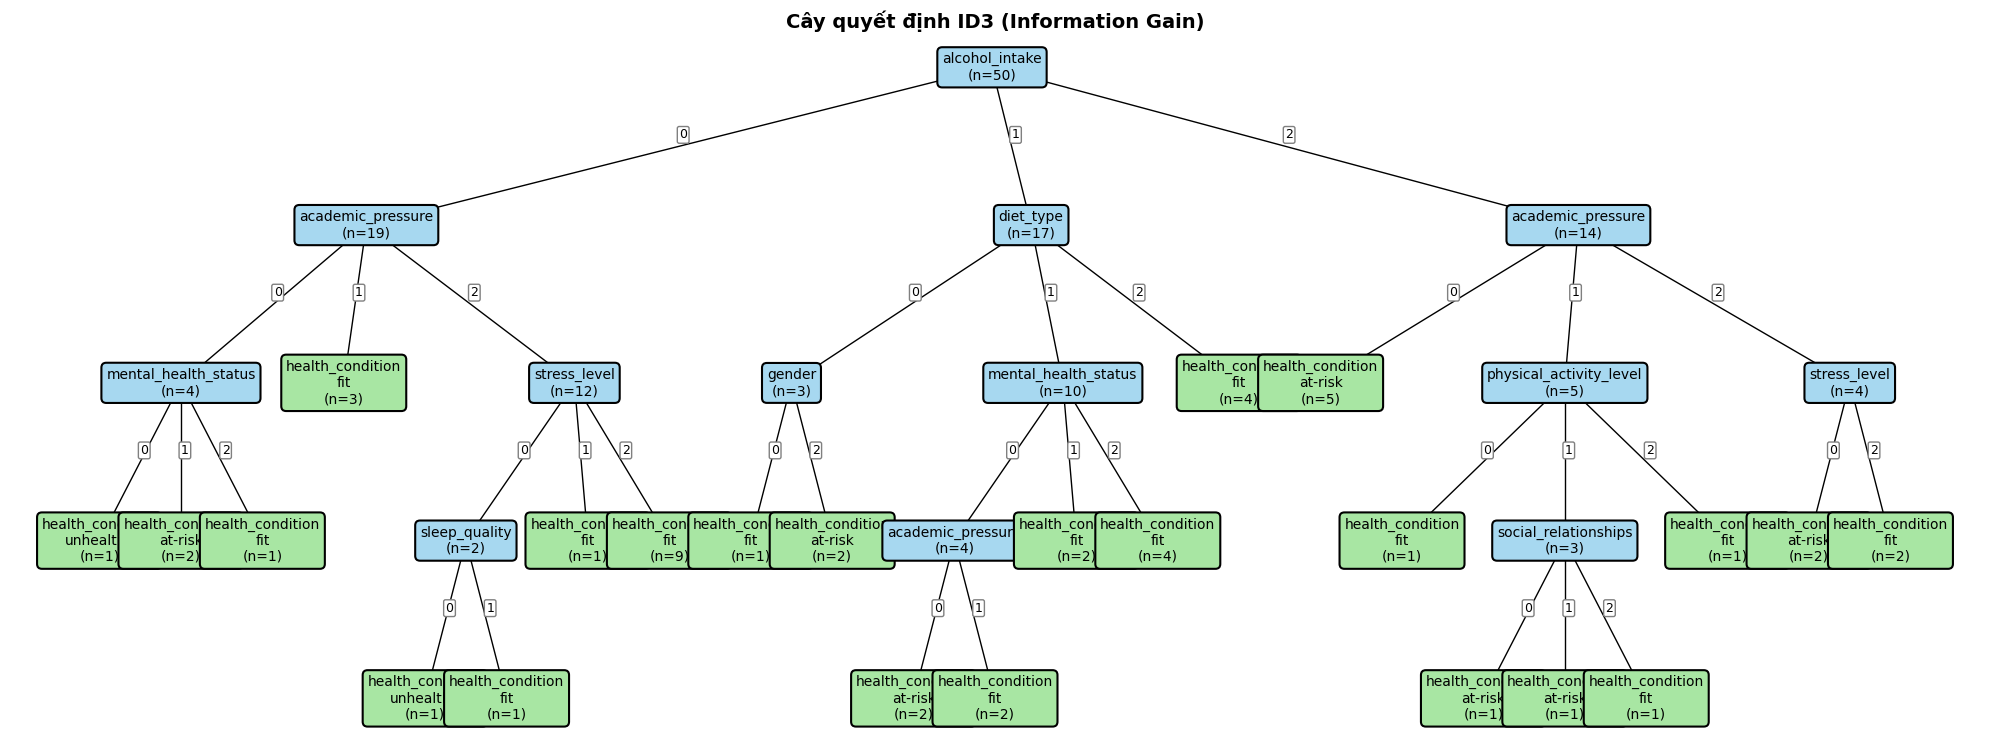


✓ Cell 6: Cây quyết định ID3 (Information Gain) hoàn tất trên 20 mẫu đầu tiên!


In [23]:
# Cell 5: Cây quyết định ID3 (Information Gain)
import pandas as pd
import math
from sklearn.preprocessing import LabelEncoder
from collections import Counter
import matplotlib.pyplot as plt

# Chuẩn bị dữ liệu (loại bỏ health_condition và student_id)
cols_to_drop = ['health_condition', 'student_id', 'timestamp', 'sleep_duration', 'heart_rate','bmi','calorie_expenditure','sitting_time','screen_time', 'step_count','exercise_duration','water_intake']  

X = df.drop(cols_to_drop, axis=1, errors='ignore').copy()
y = df['health_condition']

# Encode categorical columns
le_cols = {}
for col in X.select_dtypes(include='object').columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    le_cols[col] = le

# Ghép lại để có dữ liệu đầy đủ
df_work = pd.concat([X, y], axis=1)
target_col = 'health_condition'
feature_cols = [c for c in df_work.columns if c != target_col]

print('Dữ liệu đầu vào:')
print(f"Số mẫu: {len(df_work)} | Thuộc tính quyết định: {target_col}")
print(f"Các thuộc tính: {feature_cols}")

# =========================
# Hàm tính Information (Entropy) và Gain
# =========================
def entropy(series):
    total = len(series)
    if total == 0:
        return 0.0
    counts = Counter(series)
    e = 0.0
    for count in counts.values():
        p = count / total
        if p > 0:
            e -= p * math.log2(p)
    return e


def information_gain(data, attr, decision_attr):
    info_decision = entropy(data[decision_attr])
    weighted_info = 0.0

    for v, subset in data.groupby(attr):
        weighted_info += (len(subset) / len(data)) * entropy(subset[decision_attr])

    gain = info_decision - weighted_info
    return info_decision, weighted_info, gain


def gain_table(data, attrs, decision_attr):
    rows = []
    info_decision = entropy(data[decision_attr])
    for a in attrs:
        _, weighted_info, g = information_gain(data, a, decision_attr)
        rows.append({
            'Thuộc tính': a,
            'Info thuộc tính (sau chia)': round(weighted_info, 6),
            'Gain': round(g, 6)
        })
    table = pd.DataFrame(rows).sort_values('Gain', ascending=False).reset_index(drop=True)
    return info_decision, table


# =========================
# Xây dựng ID3 đúng quy trình
# =========================
class Node:
    def __init__(self, attribute=None, label=None):
        self.attribute = attribute
        self.label = label
        self.children = {}
        self.majority_label = None
        self.sample_count = 0


def id3(data, attrs, decision_attr, path_text='Gốc', depth=0):
    node = Node()
    node.sample_count = len(data)
    node.majority_label = data[decision_attr].mode()[0]

    print('\n' + '=' * 90)
    print(f"BƯỚC {depth + 1} | {path_text}")
    print(f"Số mẫu: {len(data)}")

    # Điều kiện dừng 1: tập thuần nhất
    unique_labels = data[decision_attr].unique()
    if len(unique_labels) == 1:
        node.label = unique_labels[0]
        print(f"Tập thuần nhất -> tạo lá: {node.label}")
        return node

    # Điều kiện dừng 2: hết thuộc tính để chia
    if not attrs:
        node.label = node.majority_label
        print(f"Hết thuộc tính -> tạo lá theo đa số: {node.label}")
        return node

    # Tính Information(I) cho thuộc tính quyết định và Gain cho từng thuộc tính
    info_decision, table = gain_table(data, attrs, decision_attr)
    print(f"Information I({decision_attr}) = {info_decision:.6f}")
    print('Bảng Gain:')
    print(table.to_string(index=False))

    # Chọn thuộc tính có Gain cao nhất
    best_attr = table.iloc[0]['Thuộc tính']
    best_gain = table.iloc[0]['Gain']

    if best_gain <= 1e-12:
        node.label = node.majority_label
        print(f"Gain tối đa ~ 0 -> tạo lá theo đa số: {node.label}")
        return node

    node.attribute = best_attr
    print(f"=> Chọn thuộc tính phân lớp: {best_attr} (Gain = {best_gain:.6f})")

    # Lặp lại quá trình trên các bảng con
    remaining_attrs = [a for a in attrs if a != best_attr]
    for v in sorted(data[best_attr].unique()):
        subset = data[data[best_attr] == v]
        print(f"\nTách nhánh: {best_attr} = {v} | số mẫu = {len(subset)}")

        if subset.empty:
            leaf = Node(label=node.majority_label)
            leaf.sample_count = 0
            leaf.majority_label = node.majority_label
            node.children[v] = leaf
        else:
            child_path = f"{path_text} -> {best_attr}={v}"
            node.children[v] = id3(subset, remaining_attrs, decision_attr, child_path, depth + 1)

    return node


# =========================
# In cây
# =========================
def print_tree(node, indent=''):
    if node.label is not None:
        print(f"{indent}THEN {target_col} = {node.label} (mẫu: {node.sample_count})")
        return

    print(f"{indent}[Chia theo: {node.attribute}] (mẫu: {node.sample_count})")
    for value, child in node.children.items():
        print(f"{indent}IF {node.attribute} = {value}")
        print_tree(child, indent + '    ')


# =========================
# Vẽ cây
# =========================
def count_leaves(node):
    if node.label is not None:
        return 1
    return sum(count_leaves(child) for child in node.children.values())


def tree_depth(node):
    if node.label is not None:
        return 1
    return 1 + max(tree_depth(child) for child in node.children.values())


def assign_positions(node, x=0, y=0, pos=None, edges=None, x_state=None):
    if pos is None:
        pos = {}
    if edges is None:
        edges = []
    if x_state is None:
        x_state = {'x': 0}

    node_id = id(node)

    if node.label is not None:
        pos[node_id] = (x_state['x'], -y)
        x_state['x'] += 1
    else:
        child_ids = []
        for val, child in node.children.items():
            assign_positions(child, y=y + 1, pos=pos, edges=edges, x_state=x_state)
            child_ids.append(id(child))
            edges.append((node_id, id(child), f"{val}"))

        child_x = [pos[cid][0] for cid in child_ids]
        pos[node_id] = (sum(child_x) / len(child_x), -y)

    return pos, edges


def draw_id3_tree(root_node):
    pos, edges = assign_positions(root_node)
    depth = tree_depth(root_node)
    leaves = count_leaves(root_node)

    # Giới hạn kích thước tối đa để tránh lỗi
    max_w = 20 
    max_h = 10
    
    # Tính toán kích thước, nhưng không vượt quá mức cho phép
    fig_w = min(max_w, leaves * 1.5)
    fig_h = min(max_h, depth * 1.5)
    
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    # Vẽ cạnh
    for parent, child, label in edges:
        x1, y1 = pos[parent]
        x2, y2 = pos[child]
        ax.plot([x1, x2], [y1, y2], color='black', linewidth=1)
        ax.text((x1 + x2) / 2, (y1 + y2) / 2 + 0.05, label, fontsize=9,
                bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.15'))

    # Vẽ nút
    def walk(node):
        nid = id(node)
        x, y = pos[nid]
        if node.label is not None:
            color = '#A8E6A3'
            text = f"{target_col}\n{node.label}\n(n={node.sample_count})"
        else:
            color = '#A7D8F0'
            text = f"{node.attribute}\n(n={node.sample_count})"

        ax.text(x, y, text, ha='center', va='center', fontsize=10,
                bbox=dict(boxstyle='round,pad=0.35', facecolor=color, edgecolor='black', linewidth=1.5))

        for c in node.children.values():
            walk(c)

    walk(root_node)

    ax.set_title('Cây quyết định ID3 (Information Gain)', fontsize=14, weight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.show()


# =========================
# Chạy toàn bộ quy trình
# =========================
print('\n' + '=' * 90)
print('XÂY DỰNG CÂY ID3 THEO QUY TRÌNH: I -> GAIN -> CHỌN THUỘC TÍNH -> LẶP TRÊN BẢNG CON')
print('=' * 90)

# Chọn 20 mẫu đầu tiên
df_sample = df_work.head(50)
root = id3(df_sample, feature_cols, target_col)

print('\n' + '=' * 90)
print('CẤU TRÚC CÂY')
print('=' * 90)
print_tree(root)

draw_id3_tree(root)

print("\n✓ Cell 5: Cây quyết định ID3 (Information Gain) hoàn tất trên 20 mẫu đầu tiên!")

Đang chạy K-Means tự xây dựng với k=3...
-> Thuật toán K-Means hội tụ tại vòng lặp thứ 41 (nhóm không thay đổi)

Custom K-Means Clustering Results (k=3):
Silhouette Score: 0.0521
Davies-Bouldin Index: 3.6569
Cluster sizes: [16715 16603 16682]


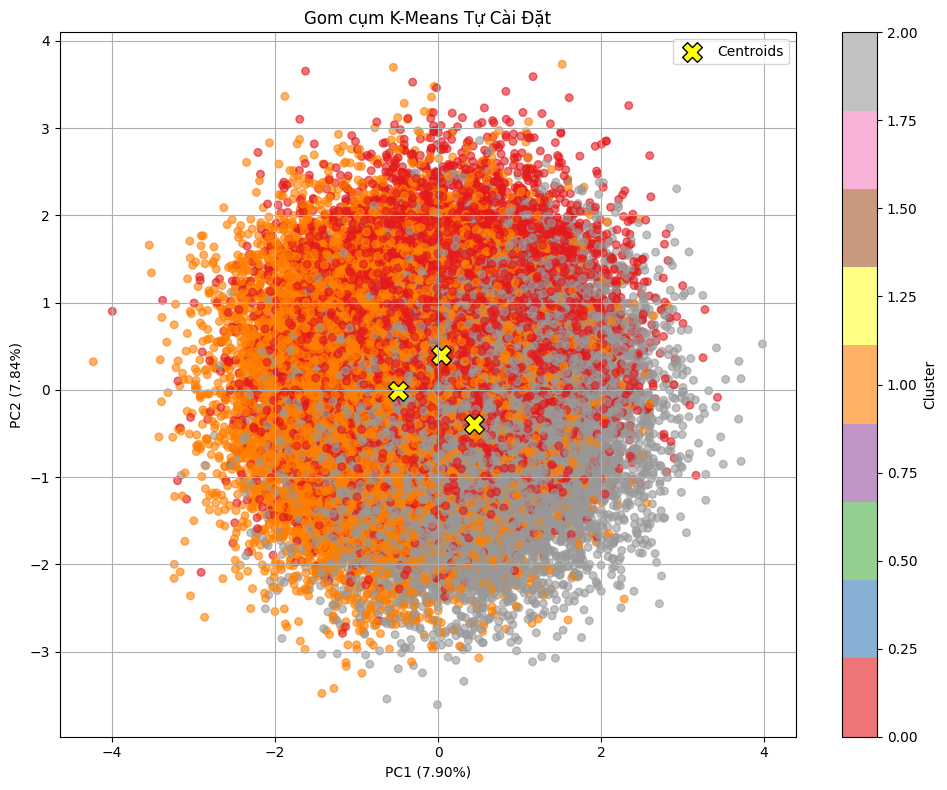


✓ Cell 6: Gom cụm K-Means hoàn tất!


In [9]:
# Cell 6: Gom cụm K-Means (Tự xây dựng)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Chuẩn bị dữ liệu
cols_to_drop = ['health_condition', 'student_id', 'timestamp']
X_raw = df.drop(columns=[c for c in cols_to_drop if c in df.columns]).copy()

# Encode categorical columns
for col in X_raw.select_dtypes(include='object').columns:
    le = LabelEncoder()
    X_raw[col] = le.fit_transform(X_raw[col].astype(str))

# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# Xây dựng thuật toán K-Means từ đầu
class CustomKMeans:
    # Bước 1: Cài đặt hàm khởi tạo __init__()
    def __init__(self, n_clusters=3, max_iters=100):
        # Lưu số cụm, số lần lặp, trọng tâm và nhãn dữ liệu
        self.n_clusters = n_clusters
        self.max_iters = max_iters
        self.centroids = None
        self.labels = None

    # Bước 2: Cài đặt hàm phân cụm ngẫu nhiên cho dòng dữ liệu
    def initialize_random_clusters(self, X):
        np.random.seed(42)
        n_samples = X.shape[0]
        
        # Chọn ngẫu nhiên n_clusters điểm dữ liệu để làm tâm cụm ban đầu
        random_indices = np.random.choice(n_samples, self.n_clusters, replace=False)
        self.centroids = X[random_indices].copy()
        
        # Gán điểm dữ liệu vào cụm (phân bổ ngẫu nhiên từng điểm dữ liệu vào một cụm)
        self.labels = np.random.randint(0, self.n_clusters, n_samples)
        
        # Lưu trong dictionary initial_clusters
        initial_clusters = {i: [] for i in range(self.n_clusters)}
        for idx, label in enumerate(self.labels):
            initial_clusters[label].append(X[idx])
            
        # Tính toán lại tâm cụm sau khi gán dữ liệu (trung bình tọa độ)
        for i in range(self.n_clusters):
            if len(initial_clusters[i]) > 0:
                self.centroids[i] = np.mean(initial_clusters[i], axis=0)
                
        # Trả về labels và centroids
        return self.labels, self.centroids

    # Bước 3: Cài đặt hàm fit thực hiện K-Means
    def fit(self, X):
        # Khởi tạo ngẫu nhiên ban đầu
        self.initialize_random_clusters(X)
        n_samples = X.shape[0]
        
        for iteration in range(self.max_iters):
            prev_centroids = self.centroids.copy()
            prev_labels = self.labels.copy()
            
            # Lập ma trận khoảng cách: dòng là điểm dữ liệu, cột là khoảng cách đến centroids
            distances = np.zeros((n_samples, self.n_clusters))
            
            # Tính khoảng cách Euclidean của từng điểm đến cụm
            for i in range(self.n_clusters):
                # Lưu kết quả vào cột thứ i của ma trận distances
                distances[:, i] = np.linalg.norm(X - self.centroids[i], axis=1)
                
            # Gán điểm vào cụm gần nhất
            self.labels = np.argmin(distances, axis=1)
            
            # Tính lại vector trọng tâm của các cụm
            for i in range(self.n_clusters):
                cluster_points = X[self.labels == i]
                if len(cluster_points) > 0:
                    self.centroids[i] = np.mean(cluster_points, axis=0)
                    
            # Dừng vòng lặp khi điểm thuộc cụm không còn thay đổi nữa
            if np.all(self.labels == prev_labels):
                print(f"-> Thuật toán K-Means hội tụ tại vòng lặp thứ {iteration + 1} (nhóm không thay đổi)")
                break

# Bước 4: Khởi chạy K-means
k_optimal = 3 # Ví dụ chọn cứng K=3
print(f"Đang chạy K-Means tự xây dựng với k={k_optimal}...")
kmeans_custom = CustomKMeans(n_clusters=k_optimal, max_iters=100)
kmeans_custom.fit(X_scaled)

clusters = kmeans_custom.labels

# Đánh giá bằng metric của sklearn cho nhanh
silhouette = silhouette_score(X_scaled, clusters)
davies_bouldin = davies_bouldin_score(X_scaled, clusters)

print(f"\nCustom K-Means Clustering Results (k={k_optimal}):")
print(f"Silhouette Score: {silhouette:.4f}")
print(f"Davies-Bouldin Index: {davies_bouldin:.4f}")
print(f"Cluster sizes: {np.bincount(clusters)}")

# Visualize clusters (Sử dụng PCA để giảm xuóng 2 chiều)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
centroids_pca = pca.transform(kmeans_custom.centroids)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='Set1', alpha=0.6, s=30)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], c='yellow', marker='X', s=200, edgecolors='black', label='Centroids')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
plt.title('Gom cụm K-Means Tự Cài Đặt')
plt.colorbar(scatter, label='Cluster')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("\n✓ Cell 6: Gom cụm K-Means hoàn tất!")

THUẬT TOÁN KOHONEN SELF-ORGANIZING MAP - THỰC HIỆN THEO 8 BƯỚC

📊 Dùng mẫu 5000/50000 để huấn luyện SOM
📈 Số mẫu: 5000 | Số chiều: 15

BƯỚC 0: Khởi tạo giá trị của các vector trọng số. Gán giá trị cho R và α
✓ Khởi tạo mạng lưới: 33 hàng x 34 cột (1122 nơ-ron)
✓ Bán kính vùng láng giềng ban đầu (R): 17.00
✓ Tốc độ học ban đầu (α): 0.5
✓ Số lần lặp tối đa: 20

📌 Một số vector trọng số ban đầu:
   w[0,0] = (-0.25, 0.90, 0.46, ...)
   w[0,1] = (-0.63, -0.39, 0.05, ...)
   w[0,2] = (0.22, -0.66, -0.87, ...)
   w[1,0] = (0.23, -0.16, 0.87, ...)
   w[1,1] = (-0.06, -0.17, -0.45, ...)
   w[1,2] = (0.91, 0.21, -0.54, ...)
   w[2,0] = (0.39, -0.41, 0.85, ...)
   w[2,1] = (0.39, -0.32, 0.45, ...)
   w[2,2] = (0.75, 0.06, 0.88, ...)

LẦN LẶP THỨ 1

• Xét mẫu đầu tiên (Mẫu 1):
  Vector đầu vào x₁ = [-0.21360324 -0.0179986  -0.22123289]... (chiều 15)

  Khoảng cách từ x₁ đến các nơron:
    D(0,0) = 4.4356    D(0,1) = 3.6901    D(0,2) = 4.0868
    D(1,0) = 3.0398    D(1,1) = 3.3020    D(1,2) = 3.399

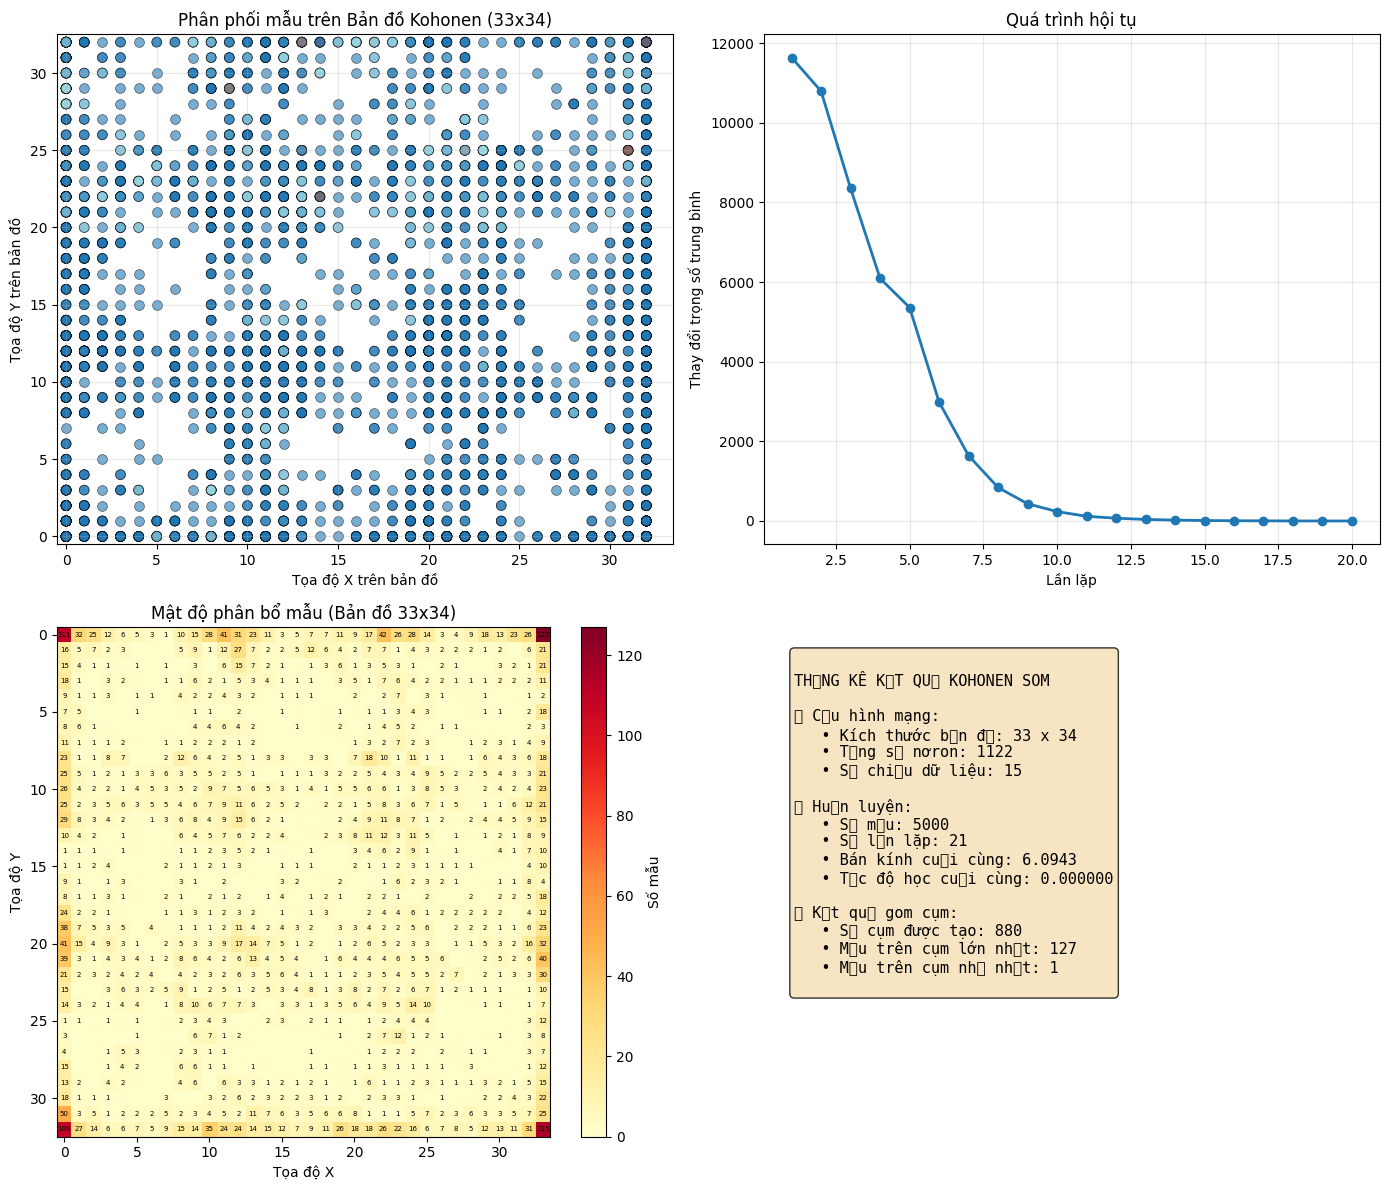


✓ Cell 7: Gom cụm mạng Kohonen (theo quy trình 8 bước - ma trận 33x34) hoàn tất!


In [10]:
# Cell 7: Gom cum Mang Kohonen (Self-Organizing Map) - Theo đúng quy trình 8 bước
from sklearn.preprocessing import StandardScaler, LabelEncoder
import matplotlib.pyplot as plt
import numpy as np
import gc
import time

print("=" * 100)
print("THUẬT TOÁN KOHONEN SELF-ORGANIZING MAP - THỰC HIỆN THEO 8 BƯỚC")
print("=" * 100)

# ==================== CHUẨN BỊ DỮ LIỆU ====================
X = df.drop('health_condition', axis=1).copy()
y_true = df['health_condition']

# Encode categorical columns
for col in X.select_dtypes(include='object').columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str)    )

# Lấy mẫu để tiết kiệm RAM
MAX_SAMPLES = 5000
if len(X) > MAX_SAMPLES:
    rng = np.random.default_rng(42)
    sample_indices = rng.choice(len(X), size=MAX_SAMPLES, replace=False)
    X_work = X.iloc[sample_indices].copy().reset_index(drop=True)
    y_work = y_true.iloc[sample_indices].copy().reset_index(drop=True)
    print(f"\n📊 Dùng mẫu {MAX_SAMPLES}/{len(X)} để huấn luyện SOM")
else:
    X_work = X.reset_index(drop=True)
    y_work = y_true.reset_index(drop=True)

# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_work).astype(np.float32)

num_features = X_scaled.shape[1]
num_samples = X_scaled.shape[0]

print(f"📈 Số mẫu: {num_samples} | Số chiều: {num_features}")

# ==================== BƯỚC 0: KHỞI TẠO ====================
print("\n" + "=" * 100)
print("BƯỚC 0: Khởi tạo giá trị của các vector trọng số. Gán giá trị cho R và α")
print("=" * 100)

rows = 33
cols = 34
map_size = (rows, cols)

# Siêu tham số
R = max(rows, cols) / 2  # Bán kính vùng láng giềng ban đầu
alpha = 0.5              # Tốc độ học ban đầu
max_iterations = 20      # Giảm số lần lặp vì ma trận lớn tốn thời gian hơn

np.random.seed(42)
# Trọng số ma trận (33, 34, num_features)
weights = np.random.uniform(-1, 1, (rows, cols, num_features)).astype(np.float32)

# Tạo lưới tọa độ để tính khoảng cách nơ-ron nhanh hơn bằng vector
row_indices, col_indices = np.indices((rows, cols))

print(f"✓ Khởi tạo mạng lưới: {rows} hàng x {cols} cột ({rows*cols} nơ-ron)")
print(f"✓ Bán kính vùng láng giềng ban đầu (R): {R:.2f}")
print(f"✓ Tốc độ học ban đầu (α): {alpha}")
print(f"✓ Số lần lặp tối đa: {max_iterations}")

# Hiển thị một số vector trọng số ban đầu
print("\n📌 Một số vector trọng số ban đầu:")
for i in range(min(3, rows)):
    for j in range(min(3, cols)):
        w = weights[i, j]
        w_display = ", ".join([f"{v:.2f}" for v in w[:3]])
        print(f"   w[{i},{j}] = ({w_display}, ...)")

# ==================== BƯỚC 1-8: LẶP HUẤN LUYỆN ====================
iteration = 1
convergence_threshold = 1e-5
prev_weights = weights.copy()
weight_changes = []

while iteration <= max_iterations:
    print("\n" + "=" * 100)
    print(f"LẦN LẶP THỨ {iteration}")
    print("=" * 100)
    
    start_iter = time.time()
    iteration_changes = []
    
    # Xáo trộn dữ liệu mỗi lần lặp để tăng hiệu quả
    indices = np.arange(num_samples)
    np.random.shuffle(indices)
    
    # Lặp qua từng mẫu dữ liệu
    for sample_count, idx in enumerate(indices):
        # BƯỚC 2: Lấy vector đầu vào
        x = X_scaled[idx]
        
        # BƯỚC 3: Tính khoảng cách Euclide từ x đến tất cả nơron
        distances = np.zeros((rows, cols))
        for i in range(rows):
            for j in range(cols):
                distances[i, j] = np.sqrt(np.sum((x - weights[i, j]) ** 2))
        
        # BƯỚC 4: Tìm nơron chiến thắng (winner)
        winner_i, winner_j = np.unravel_index(np.argmin(distances), distances.shape)
        min_distance = distances[winner_i, winner_j]
        
        # Hiển thị chi tiết cho mẫu đầu tiên
        if sample_count == 0 and iteration == 1:
            print(f"\n• Xét mẫu đầu tiên (Mẫu 1):")
            print(f"  Vector đầu vào x₁ = {x[:3]}... (chiều {num_features})")
            print(f"\n  Khoảng cách từ x₁ đến các nơron:")
            for i in range(min(3, rows)):
                for j in range(min(3, cols)):
                    d = distances[i, j]
                    print(f"    D({i},{j}) = {d:.4f}", end="")
                print()
            print(f"\n  → Nơron chiến thắng: w[{winner_i},{winner_j}] (khoảng cách: {min_distance:.4f})")
        
        # BƯỚC 5: Cập nhật trọng số nơron chiến thắng và láng giềng
        for i in range(rows):
            for j in range(cols):
                # Tính khoảng cách từ nơron đến nơron chiến thắng
                neuron_distance = np.sqrt((i - winner_i) ** 2 + (j - winner_j) ** 2)
                
                # Kiểm tra xem nơron có nằm trong vùng láng giềng không
                if neuron_distance <= R:
                    # Cập nhật trọng số theo công thức
                    delta = alpha * (x - weights[i, j])
                    weights[i, j] += delta
                    
                    if sample_count == 0 and iteration == 1 and i == winner_i and j == winner_j:
                        print(f"\n  Cập nhật nơron chiến thắng w[{i},{j}]:")
                        for k in range(min(3, num_features)):
                            old_w = weights[i, j, k] - delta[k]
                            new_w = weights[i, j, k]
                            print(f"    w[{i},{j},{k}] = {old_w:.4f} + {alpha:.1f} × ({x[k]:.4f} - {old_w:.4f}) = {new_w:.4f}")
        
        iteration_changes.append(np.sum(np.abs(weights - prev_weights)))
    
    prev_weights = weights.copy()
    avg_change = np.mean(iteration_changes)
    weight_changes.append(avg_change)
    
    # BƯỚC 6: Cập nhật tốc độ học α
    alpha = 0.5 * alpha
    
    # BƯỚC 7: Giảm bán kính vùng láng giềng
    R = R * 0.95
    
    print(f"\n  Tổng mẫu xử lý: {num_samples}")
    print(f"  Thay đổi trọng số trung bình: {avg_change:.6f}")
    print(f"  α mới: {alpha:.6f}")
    print(f"  R mới: {R:.4f}")
    
    # BƯỚC 8: Kiểm tra điều kiện dừng
    if avg_change < convergence_threshold:
        print(f"\n✓ Hội tụ tại lần lặp {iteration} (thay đổi < {convergence_threshold})")
        break
    
    iteration += 1

print("\n" + "=" * 100)
print("✓ Huấn luyện hoàn tất!")
print("=" * 100)

# ==================== PHÂN CỤM DỮ LIỆU ====================
print("\n📊 GÁN CỤM DỮ LIỆU")
print("=" * 100)

# Gán mỗi mẫu vào nơron chiến thắng
winning_neurons = np.zeros((num_samples, 2), dtype=int)
for sample_idx in range(num_samples):
    x = X_scaled[sample_idx]
    distances = np.zeros((rows, cols))
    for i in range(rows):
        for j in range(cols):
            distances[i, j] = np.sqrt(np.sum((x - weights[i, j]) ** 2))
    winner_i, winner_j = np.unravel_index(np.argmin(distances), distances.shape)
    winning_neurons[sample_idx] = [winner_i, winner_j]

# Đếm số lượng mẫu trong mỗi cụm
cluster_counts = {}
for i in range(rows):
    for j in range(cols):
        count = np.sum((winning_neurons[:, 0] == i) & (winning_neurons[:, 1] == j))
        if count > 0:
            cluster_counts[(i, j)] = count
            print(f"Cụm w[{i},{j}]: {count} mẫu")

# ==================== VISUALIZATION ====================
print("\n📈 HIỂN THỊ KẾT QUẢ")
print("=" * 100)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Plot 1: Phân phối mẫu trên bản đồ Kohonen
ax = axes[0, 0]
y_codes = pd.factorize(y_work.astype(str))[0]

for (i, j) in cluster_counts.keys():
    mask = (winning_neurons[:, 0] == i) & (winning_neurons[:, 1] == j)
    ax.scatter(winning_neurons[mask, 0], winning_neurons[mask, 1],
              c=y_codes[mask], cmap='tab20', alpha=0.6, s=50, edgecolors='black', linewidth=0.5)

ax.set_xlabel('Tọa độ X trên bản đồ')
ax.set_ylabel('Tọa độ Y trên bản đồ')
ax.set_title('Phân phối mẫu trên Bản đồ Kohonen (33x34)')
ax.grid(True, alpha=0.3)
ax.set_xlim([-0.5, cols - 0.5])
ax.set_ylim([-0.5, rows - 0.5])

# Plot 2: Thay đổi trọng số qua các lần lặp
ax = axes[0, 1]
ax.plot(range(1, len(weight_changes) + 1), weight_changes, marker='o', linewidth=2, markersize=6)
ax.set_xlabel('Lần lặp')
ax.set_ylabel('Thay đổi trọng số trung bình')
ax.set_title('Quá trình hội tụ')
ax.grid(True, alpha=0.3)

# Plot 3: Ma trận cấu trúc
ax = axes[1, 0]
structure_map = np.zeros((rows, cols))
for (i, j), count in cluster_counts.items():
    structure_map[i, j] = count

im = ax.imshow(structure_map, cmap='YlOrRd', aspect='auto')

# Hiển thị số lượng mẫu cho TẤT CẢ các ô có dữ liệu > 0
for i in range(rows): # Bỏ min(8, rows)
    for j in range(cols): # Bỏ min(8, cols)
        if structure_map[i, j] > 0:
            # Chỉ hiện số nếu mật độ đủ lớn hoặc bạn muốn xem chi tiết
            # Với map 33x34, chữ sẽ rất nhỏ, nên dùng fontsize nhỏ (ví dụ: 5 hoặc 6)
            ax.text(j, i, f'{int(structure_map[i, j])}',
                    ha="center", va="center", color="black", fontsize=5)

ax.set_xlabel('Tọa độ X')
ax.set_ylabel('Tọa độ Y')
ax.set_title(f'Mật độ phân bổ mẫu (Bản đồ {rows}x{cols})')
plt.colorbar(im, ax=ax, label='Số mẫu')

# Plot 4: Thống kê
ax = axes[1, 1]
ax.axis('off')
stats_text = f"""
THỐNG KÊ KẾT QUẢ KOHONEN SOM

📌 Cấu hình mạng:
   • Kích thước bản đồ: {rows} x {cols}
   • Tổng số nơron: {rows * cols}
   • Số chiều dữ liệu: {num_features}

📊 Huấn luyện:
   • Số mẫu: {num_samples}
   • Số lần lặp: {iteration}
   • Bán kính cuối cùng: {R:.4f}
   • Tốc độ học cuối cùng: {alpha:.6f}

🎯 Kết quả gom cụm:
   • Số cụm được tạo: {len(cluster_counts)}
   • Mẫu trên cụm lớn nhất: {max(cluster_counts.values())}
   • Mẫu trên cụm nhỏ nhất: {min(cluster_counts.values())}
"""
ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

# ==================== GIẢI PHÓNG BỘ NHỚ ====================
del X_work, y_work, X_scaled, weights
gc.collect()

print("\n✓ Cell 7: Gom cụm mạng Kohonen (theo quy trình 8 bước - ma trận 33x34) hoàn tất!")

SO SÁNH KẾT QUẢ GOM CỤM: K-MEANS vs KOHONEN (SOM)
✓ Dữ liệu dùng so sánh: 5000 mẫu, 15 thuộc tính

🟢 Huấn luyện Kohonen SOM...
✓ Kohonen: map=2x2, số cụm thực tế=4

🔵 Huấn luyện K-Means...
✓ K-Means: k=4

BẢNG SO SÁNH METRICS
  Phương pháp  Silhouette  Davies-Bouldin  Calinski-Harabasz  n_clusters
      K-Means      0.0431          3.5009           209.1149           4
Kohonen (SOM)      0.0444          3.5834           201.9006           4


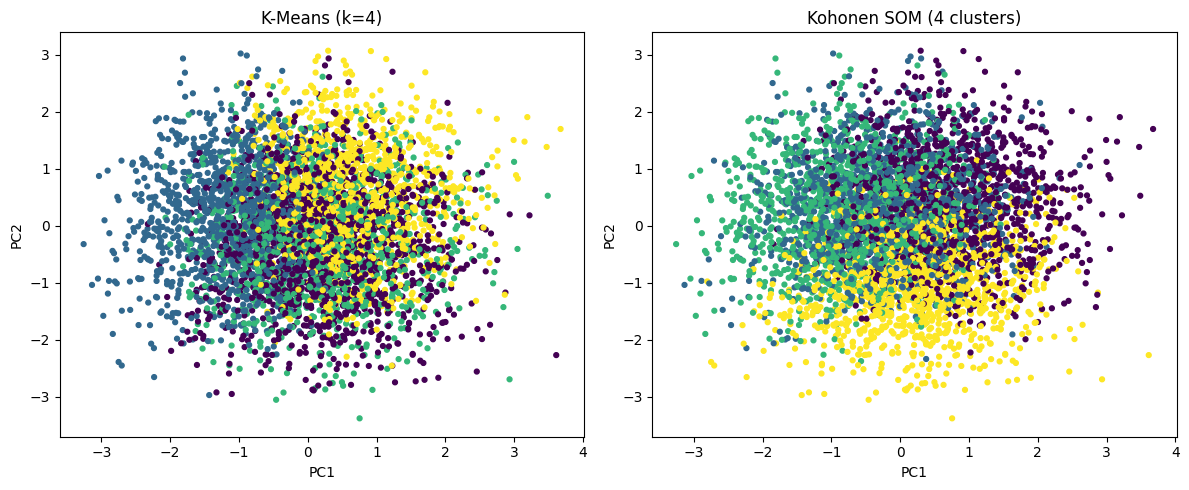


✓ So sánh K-Means vs Kohonen hoàn tất!


In [11]:
# So sánh K-Means và Kohonen (SOM)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

print("=" * 100)
print("SO SÁNH KẾT QUẢ GOM CỤM: K-MEANS vs KOHONEN (SOM)")
print("=" * 100)

# 1) Dữ liệu chung
X_raw = df.drop('health_condition', axis=1).copy()

for col in X_raw.select_dtypes(include='object').columns:
    le = LabelEncoder()
    X_raw[col] = le.fit_transform(X_raw[col].astype(str))

MAX_SAMPLES = 5000
if len(X_raw) > MAX_SAMPLES:
    rng = np.random.default_rng(42)
    sample_idx = rng.choice(len(X_raw), size=MAX_SAMPLES, replace=False)
    X_work = X_raw.iloc[sample_idx].reset_index(drop=True)
else:
    X_work = X_raw.reset_index(drop=True)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_work).astype(np.float32)

print(f"✓ Dữ liệu dùng so sánh: {X_scaled.shape[0]} mẫu, {X_scaled.shape[1]} thuộc tính")

# 2) Kohonen SOM (nhẹ để so sánh nhanh)
print("\n🟢 Huấn luyện Kohonen SOM...")

map_size_x, map_size_y = 2, 2
R = max(map_size_x, map_size_y) / 2
alpha = 0.5
max_iterations = 30

np.random.seed(42)
weights = np.random.uniform(-1, 1, (map_size_x, map_size_y, X_scaled.shape[1])).astype(np.float32)

prev_weights = weights.copy()
for _ in range(max_iterations):
    for row in range(X_scaled.shape[0]):
        x = X_scaled[row]

        distances = np.zeros((map_size_x, map_size_y), dtype=np.float32)
        for i in range(map_size_x):
            for j in range(map_size_y):
                distances[i, j] = np.sqrt(np.sum((x - weights[i, j]) ** 2))

        winner_i, winner_j = np.unravel_index(np.argmin(distances), distances.shape)

        for i in range(map_size_x):
            for j in range(map_size_y):
                neuron_distance = np.sqrt((i - winner_i) ** 2 + (j - winner_j) ** 2)
                if neuron_distance <= R:
                    weights[i, j] += alpha * (x - weights[i, j])

    avg_change = float(np.mean(np.abs(weights - prev_weights)))
    prev_weights = weights.copy()

    alpha *= 0.5
    R *= 0.95

    if avg_change < 1e-4:
        break

winning_neurons = np.zeros((X_scaled.shape[0], 2), dtype=int)
for row in range(X_scaled.shape[0]):
    x = X_scaled[row]
    distances = np.zeros((map_size_x, map_size_y), dtype=np.float32)
    for i in range(map_size_x):
        for j in range(map_size_y):
            distances[i, j] = np.sqrt(np.sum((x - weights[i, j]) ** 2))
    winner_i, winner_j = np.unravel_index(np.argmin(distances), distances.shape)
    winning_neurons[row] = [winner_i, winner_j]

cluster_map = {}
kohonen_labels = np.zeros(X_scaled.shape[0], dtype=int)
label_counter = 0
for idx, (i, j) in enumerate(winning_neurons):
    key = (int(i), int(j))
    if key not in cluster_map:
        cluster_map[key] = label_counter
        label_counter += 1
    kohonen_labels[idx] = cluster_map[key]

kohonen_k = int(len(np.unique(kohonen_labels)))
print(f"✓ Kohonen: map={map_size_x}x{map_size_y}, số cụm thực tế={kohonen_k}")

# 3) K-Means (đặt k giống Kohonen để so sánh)
print("\n🔵 Huấn luyện K-Means...")

kmeans_k = max(2, kohonen_k)
kmeans = KMeans(n_clusters=kmeans_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)
print(f"✓ K-Means: k={kmeans_k}")

# 4) Metrics

def safe_metrics(labels: np.ndarray) -> dict:
    unique = np.unique(labels)
    if len(unique) < 2:
        return {
            'Silhouette': np.nan,
            'Davies-Bouldin': np.nan,
            'Calinski-Harabasz': np.nan,
            'n_clusters': len(unique),
        }

    return {
        'Silhouette': float(silhouette_score(X_scaled, labels)),
        'Davies-Bouldin': float(davies_bouldin_score(X_scaled, labels)),
        'Calinski-Harabasz': float(calinski_harabasz_score(X_scaled, labels)),
        'n_clusters': len(unique),
    }

comparison = pd.DataFrame([
    {'Phương pháp': 'K-Means', **safe_metrics(kmeans_labels)},
    {'Phương pháp': 'Kohonen (SOM)', **safe_metrics(kohonen_labels)},
])

print("\n" + "=" * 100)
print("BẢNG SO SÁNH METRICS")
print("=" * 100)
print(comparison.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

# 5) Trực quan (PCA 2D)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, s=12, cmap='viridis')
axes[0].set_title(f'K-Means (k={kmeans_k})')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=kohonen_labels, s=12, cmap='viridis')
axes[1].set_title(f'Kohonen SOM ({kohonen_k} clusters)')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

plt.tight_layout()
plt.show()

print("\n✓ So sánh K-Means vs Kohonen hoàn tất!")